<a href="https://colab.research.google.com/github/raul0807/Algorithms-for-massive-data-project/blob/main/Garbage_Recognizer_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os

# Defining the variable for the download
token = "KGAT_9efc02091cde2962df4a38c4b09852e7"
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/sumn2u/garbage-classification-v2"
zip_filename = "garbage.zip"

print("Starting the download of the dataset...")

# using curl for download the file
os.system(f'curl -L -H "Authorization: Bearer {token}" -o {zip_filename} {dataset_url}')

print("Download done. Extraction is starting...")

# extractn the zip file
!unzip -q {zip_filename} -d garbage_data

print("The dataset is ready in the directory: 'garbage_data'.")

Inizio il download del dataset tramite URL diretto...
Download completato. Inizio l'estrazione...
replace garbage_data/original/battery/battery_1.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: Tutto fatto! Il dataset è pronto nella cartella 'garbage_data'.


In [3]:
import os
import shutil
from PIL import Image

folder_path = "garbage_data/original"
removed = 0

print("Finding phantom directories...")
for root, dirs, files in os.walk(folder_path):
    for d in dirs:
        if d == ".ipynb_checkpoints":
            path_to_delete = os.path.join(root, d)
            shutil.rmtree(path_to_delete)
            print(f"Deleted system folder: {path_to_delete}")

print("Find file that are not images...")
for root, dirs, files in os.walk(folder_path):
    for file in files:
        file_path = os.path.join(root, file)

        # Delete everything that don't seem an image
        if not file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
            print(f"Deleted suspicious file: {file}")
            os.remove(file_path)
            removed += 1
            continue

        # control on corrupted images
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            print(f"Eliminated corrupted image: {file}")
            os.remove(file_path)
            removed += 1

print(f"\nCleaning completed. Deleted {removed} file gatecrashers")

1. Caccia alle cartelle fantasma...
2. Caccia ai file non-immagine (a basso consumo di RAM)...

Pulizia completata in totale sicurezza! Eliminati 0 file intrusi.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models


# Settings and scalability

DATA_DIR = "garbage_data/original"
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

print("Uploading data...")

train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Trovate {NUM_CLASSES} classi VERE: {class_names}")

# Optimization
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)


# DATA AUGMENTATION & PREPROCESSING

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
])


# Creations of the CNN

model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


# Training

print("\nStarting...")
EPOCHS = 10

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)
print("Done")

Caricamento dei dati in corso (modalità scalabile)...
Found 12257 files belonging to 10 classes.
Using 9806 files for training.
Found 12257 files belonging to 10 classes.
Using 2451 files for validation.
Trovate 10 classi VERE: ['battery', 'biological', 'cardboard', 'clothes', 'glass', 'metal', 'paper', 'plastic', 'shoes', 'trash']

Inizio addestramento del modello...
Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 46s 72ms/step - accuracy: 0.2472 - loss: 2.1214 - val_accuracy: 0.3835 - val_loss: 1.8009
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 55s 56ms/step - accuracy: 0.3562 - loss: 1.8374 - val_accuracy: 0.4198 - val_loss: 1.7032
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.3886 - loss: 1.7487 - val_accuracy: 0.4614 - val_loss: 1.5811
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 17s 57ms/step - accuracy: 0.4087 - loss: 1.6949 - val_accuracy: 0.4590 - val_loss: 1.5471
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 57ms/step - accuracy: 0.4394 - loss: 1.6239 - val_accuracy: 0.499

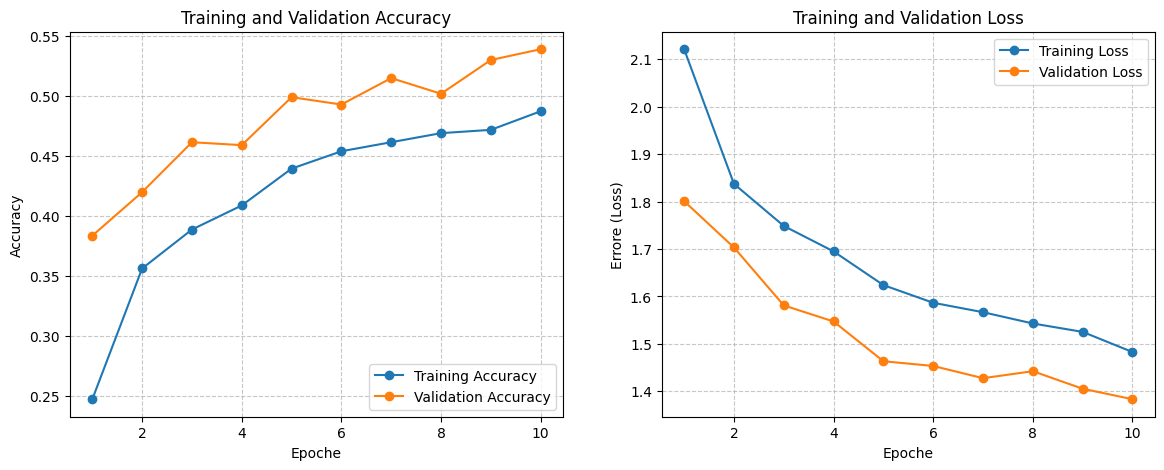

In [5]:
import matplotlib.pyplot as plt

# extracting accuracy and loss data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# create a figure with the graphs one next to the other
plt.figure(figsize=(14, 5))

# Accuracy graph (the most i goes up the better it is)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.7)

# Loss graph (the most it goes down the better is it)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoche')
plt.ylabel('Errore (Loss)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Inizio l'addestramento del Modello 2 (Learning Rate = 0.0001)...
Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.2387 - loss: 2.1139 - val_accuracy: 0.3325 - val_loss: 1.9247
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 59ms/step - accuracy: 0.3299 - loss: 1.9283 - val_accuracy: 0.4141 - val_loss: 1.7375
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 18s 58ms/step - accuracy: 0.3724 - loss: 1.8176 - val_accuracy: 0.4643 - val_loss: 1.6284


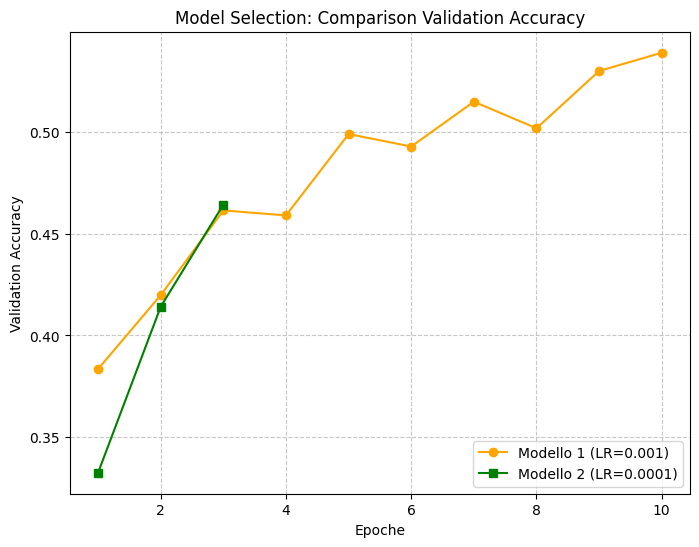

In [8]:
print("Training of Model 2 (Learning Rate = 0.0001)...")

# Creating the same neural network
model_2 = models.Sequential([
    layers.Rescaling(1./255, input_shape=(224, 224, 3)),
    data_augmentation,
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Changing the hyperparameter: Learning Rate from 0.001 to 0.0001
model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Training the second model
history_2 = model_2.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stopping],
    verbose=1
)

# Final comparison

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(val_acc) + 1), val_acc, label='Model 1 (LR=0.001)', marker='o', color='orange')
plt.plot(range(1, len(history_2.history['val_accuracy']) + 1), history_2.history['val_accuracy'], label='Model 2 (LR=0.0001)', marker='s', color='green')

plt.title('Model Selection: Comparison Validation Accuracy')
plt.xlabel('Epoche')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()